In [1]:
print("Project 2: Outfit Style Classifier")

Project 2: Outfit Style Classifier


In [2]:
import os

IMAGE_FOLDER = "../images"

files = os.listdir(IMAGE_FOLDER)

print("Number of images:", len(files))
print(files[:5])

Number of images: 25
['#outfits #fashion #summer #summerstyle.jpg', '30 Effortlessly Chic Outfits to Copy for Summer.jpg', '5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg', 'Another Day in Denim.jpg', 'download (1).jpg']


In [3]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans

def get_dominant_colors(image_path, k=3):
    image = Image.open(image_path)
    image = image.resize((100, 100))

    pixels = np.array(image).reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)

    return kmeans.cluster_centers_

In [4]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)

    try:
        colors = get_dominant_colors(path)
        feature = colors.flatten()  # convert to 1D
        all_features.append(feature)

    except:
        print("Skipped:", file)

all_features = np.array(all_features)

print("Shape:", all_features.shape)

Shape: (25, 9)


In [5]:
style_model = KMeans(n_clusters=3, random_state=42)
style_labels = style_model.fit_predict(all_features)

print(style_labels)

[2 0 0 1 1 2 1 0 2 0 0 0 2 1 1 1 2 0 0 1 2 0 2 2 2]


C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
for file, label in zip(files, style_labels):
    print(file, "→ Style Group", label)

#outfits #fashion #summer #summerstyle.jpg → Style Group 2
30 Effortlessly Chic Outfits to Copy for Summer.jpg → Style Group 0
5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg → Style Group 0
Another Day in Denim.jpg → Style Group 1
download (1).jpg → Style Group 1
download (2).jpg → Style Group 2
download (3).jpg → Style Group 1
download (4).jpg → Style Group 0
download (5).jpg → Style Group 2
download.jpg → Style Group 0
Elegant Spring Outfit Inspo _ Effortlessly Chic Cafe Baddie Look 2026.jpg → Style Group 0
Elegant Street Style _ Fashion Essentials.jpg → Style Group 0
Ellie (@slipintostyle) • Instagram photos and videos.jpg → Style Group 2
Find Out Where To Get The Top.jpg → Style Group 1
Jordan Clarkson Outfits.jpg → Style Group 1
Jordan Clarkson.jpg → Style Group 1
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → Style Group 2
lewis hamilton.jpg → Style Group 0
lucyflorals on LTK.jpg → Style Group 0
Mens Fashion.jpg → Style Group 1
Oversize 

In [7]:
style_names = {
    0: "Neutral / Minimal",
    1: "Dark / Streetwear",
    2: "Light / Casual"
}

for file, label in zip(files, style_labels):
    print(file, "→", style_names[label])

#outfits #fashion #summer #summerstyle.jpg → Light / Casual
30 Effortlessly Chic Outfits to Copy for Summer.jpg → Neutral / Minimal
5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg → Neutral / Minimal
Another Day in Denim.jpg → Dark / Streetwear
download (1).jpg → Dark / Streetwear
download (2).jpg → Light / Casual
download (3).jpg → Dark / Streetwear
download (4).jpg → Neutral / Minimal
download (5).jpg → Light / Casual
download.jpg → Neutral / Minimal
Elegant Spring Outfit Inspo _ Effortlessly Chic Cafe Baddie Look 2026.jpg → Neutral / Minimal
Elegant Street Style _ Fashion Essentials.jpg → Neutral / Minimal
Ellie (@slipintostyle) • Instagram photos and videos.jpg → Light / Casual
Find Out Where To Get The Top.jpg → Dark / Streetwear
Jordan Clarkson Outfits.jpg → Dark / Streetwear
Jordan Clarkson.jpg → Dark / Streetwear
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → Light / Casual
lewis hamilton.jpg → Neutral / Minimal
lucyflorals on LTK.jpg →

In [8]:
from collections import Counter

style_counts = Counter(style_labels)

for label, count in style_counts.items():
    print(style_names[label], ":", count, "images")

Light / Casual : 9 images
Neutral / Minimal : 9 images
Dark / Streetwear : 7 images


In [9]:
import matplotlib.pyplot as plt

def show_style_examples(style_id):
    print("Style:", style_names[style_id])
    
    count = 0
    for file, label in zip(files, style_labels):
        if label == style_id and count < 5:
            img_path = os.path.join(IMAGE_FOLDER, file)
            img = Image.open(img_path)

            plt.imshow(img)
            plt.title(style_names[style_id])
            plt.axis('off')
            plt.show()

            count += 1

Style: Neutral / Minimal


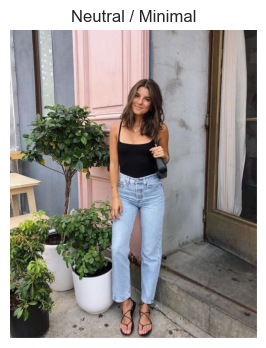

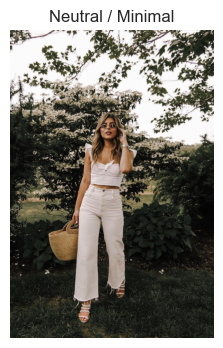

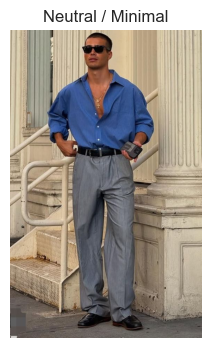

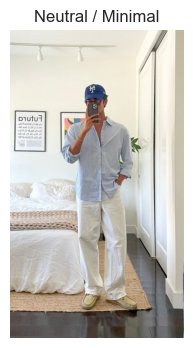

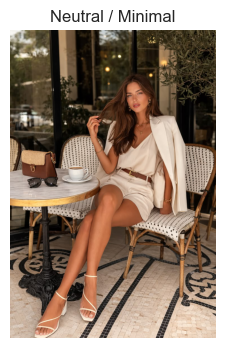

Style: Dark / Streetwear


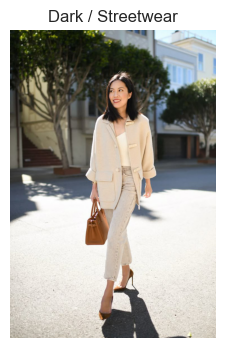

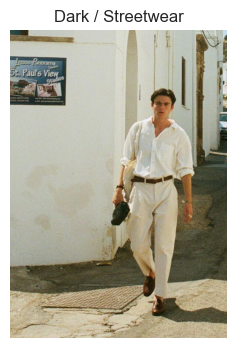

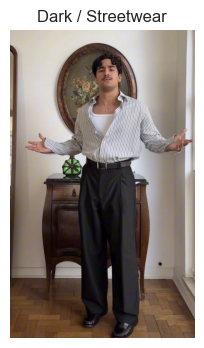

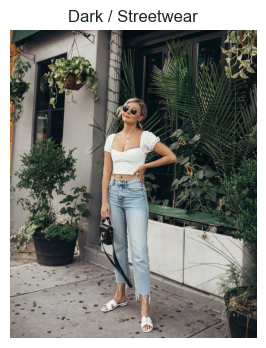

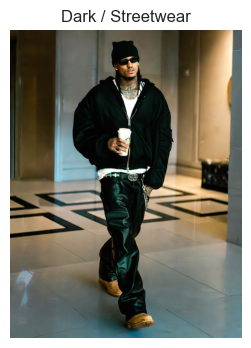

Style: Light / Casual


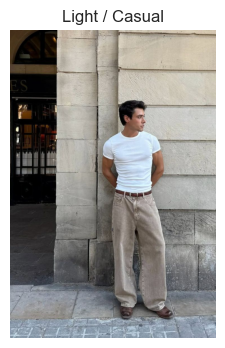

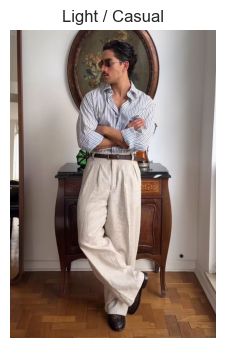

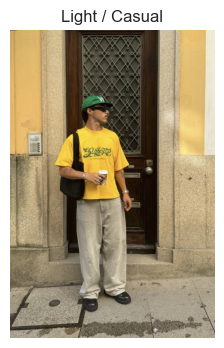

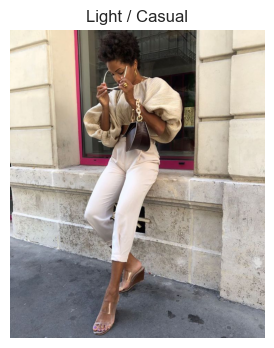

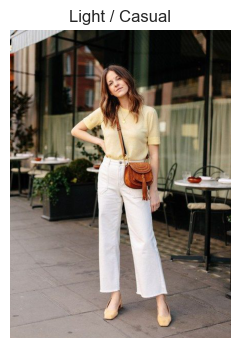

In [10]:
show_style_examples(0)
show_style_examples(1)
show_style_examples(2)